<a href="https://colab.research.google.com/github/arcctg/kpi-ml-lab5/blob/main/01_mnist_digit_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: MNIST Handwritten Digit Classification


#### Importing Required Libraries

We import the following libraries for this task:
- **numpy (np)**: Numerical computing — array manipulations, argmax, reshaping
- **matplotlib.pyplot (plt)**: Visualizing digit images and training curves
- **tensorflow (tf)**: The backend engine powering Keras
- **tensorflow.keras.datasets.mnist**: Built-in loader for the MNIST dataset (60 000 train + 10 000 test grayscale images of handwritten digits)
- **tensorflow.keras.utils.to_categorical**: Converts integer class labels to one-hot encoded vectors required for `categorical_crossentropy` loss
- **tensorflow.keras.models / layers**: High-level API for building `Sequential` feedforward networks with `Dense` layers
- **PIL.Image**: Used later to load and preprocess custom digit images from disk

In [24]:
import os

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import models, layers
from PIL import Image

%cd ~
if not os.path.exists('kpi-ml-lab5'):
    !git clone https://github.com/arcctg/kpi-ml-lab5

%cd kpi-ml-lab5

/root
/root/kpi-ml-lab5


#### Loading the MNIST Dataset

The MNIST dataset is bundled directly inside Keras and is downloaded automatically on first use. It consists of:
- **60 000 training images** used to fit the model weights
- **10 000 test images** held out to evaluate generalisation

Each image is a **28 × 28 pixel** grayscale bitmap (one channel) stored as a `uint8` array with pixel values in the range **[0, 255]**.

Labels are integers in **[0, 9]** identifying which handwritten digit the image represents.

In [2]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print("Training set — images:", train_images.shape, "| labels:", train_labels.shape)
print("Test set     — images:", test_images.shape,  "| labels:", test_labels.shape)
print("Data type:", train_images.dtype)
print("Pixel value range: [{}, {}]".format(train_images.min(), train_images.max()))

Training set — images: (60000, 28, 28) | labels: (60000,)
Test set     — images: (10000, 28, 28) | labels: (10000,)
Data type: uint8
Pixel value range: [0, 255]


#### Visualising the First 25 Training Images

Before any preprocessing we take a quick look at the raw data. We plot the first 25 images from the training set in a 5 × 5 grid and place the corresponding digit label below each image.

This step confirms that the data was loaded correctly and gives an intuition about the variety of handwriting styles the model will learn from.

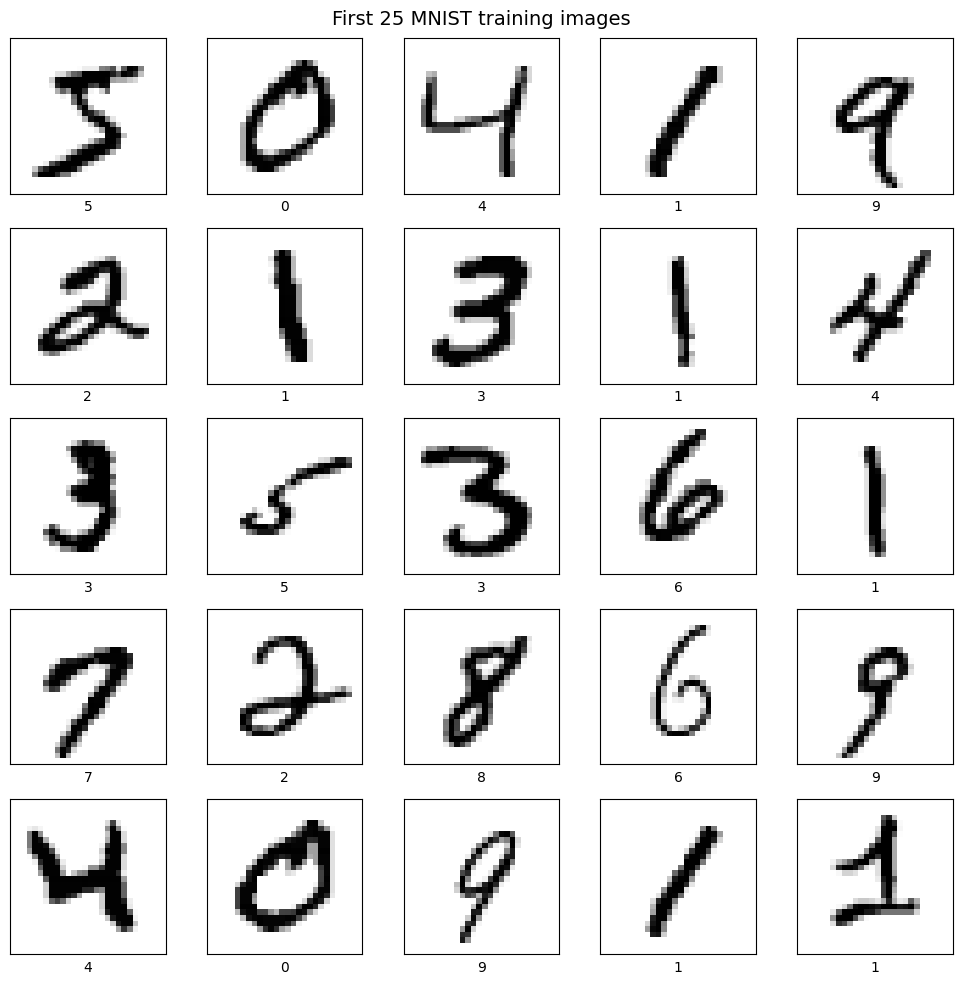

In [3]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(train_labels[i])
plt.suptitle("First 25 MNIST training images", fontsize=14)
plt.tight_layout()
plt.show()

#### Data Preprocessing — Reshape and Normalise

Two transformations are applied before feeding the data to the network:

**1. Flatten (reshape)**  
Each 28 × 28 image is unrolled into a **1-D vector of length 784**.  
This matches the `input_shape=(784,)` expected by the first `Dense` layer.

**2. Normalise to [0, 1]**  
Pixel values are divided by 255 and cast to `float32`.  
Keeping inputs in the same small numeric range as the initial random weights greatly accelerates gradient convergence and improves numerical stability.

**3. One-hot encode labels**  
`to_categorical` converts each integer label (e.g. `3`) into a binary vector of length 10  
(e.g. `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`).  
This is required by `categorical_crossentropy`, which compares two probability distributions.

In [4]:
# Flatten + normalise
train_images = train_images.reshape((60000, 28 * 28)).astype('float32') / 255
test_images  = test_images.reshape((10000,  28 * 28)).astype('float32') / 255

# One-hot encode labels
train_labels = to_categorical(train_labels)
test_labels  = to_categorical(test_labels)

print("train_images shape:", train_images.shape, "| dtype:", train_images.dtype)
print("train_labels shape:", train_labels.shape)
print("Example label vector:", train_labels[0])

train_images shape: (60000, 784) | dtype: float32
train_labels shape: (60000, 10)
Example label vector: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


#### Defining the Model Architecture

We use the `Sequential` API — a linear stack of layers where the output of each layer feeds directly into the next.

**Architecture:**

| Layer | Units | Activation | Role |
|-------|-------|-----------|------|
| Dense (hidden) | 512 | ReLU | Learns non-linear feature combinations from the 784 inputs |
| Dense (output) | 10  | Softmax | Produces a probability distribution over 10 digit classes |

**Why ReLU?**  
`f(x) = max(0, x)` is computationally cheap, avoids the vanishing-gradient problem common with sigmoid/tanh, and works well for image data.

**Why Softmax on the output?**  
It normalises the 10 raw scores so they sum to 1, making each value a valid class probability. The model's prediction is the index with the highest probability.

In [5]:
network = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(28 * 28,)),
    layers.Dense(10,  activation='softmax')
])

network.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

#### Compiling the Model

Before training, we configure three key components:

- **Optimizer — `rmsprop`**  
  Root Mean Square Propagation. It maintains a moving average of squared gradients to adaptively scale the learning rate for each weight. Works well out-of-the-box for most classification tasks.

- **Loss function — `categorical_crossentropy`**  
  The standard loss for multi-class classification when labels are one-hot encoded.  
  It measures the difference between the predicted probability distribution and the true distribution.

- **Metric — `accuracy`**  
  Fraction of correctly classified samples. Reported during training for human-readable monitoring but **not** used to update weights (that is the loss function's role).

In [6]:
network.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#### Training the Model

We call `model.fit()` to start the gradient-descent optimisation loop.

Key parameters:

- **`epochs=5`** — the entire training set is passed through the network 5 times. Each pass refines the weights further.
- **`batch_size=128`** — instead of updating weights after every single sample (SGD) or after all samples (full-batch GD), we compute gradients on mini-batches of 128 images. This balances speed and stability.
- **`validation_split=0.1`** — 10 % of the training data (6 000 images) is withheld from weight updates and used to monitor generalisation after each epoch. This helps detect overfitting early.

The returned `history` object stores the per-epoch values of all metrics for both the training and validation sets.

In [7]:
history = network.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9188 - loss: 0.2830 - val_accuracy: 0.9660 - val_loss: 0.1241
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9660 - loss: 0.1152 - val_accuracy: 0.9743 - val_loss: 0.0897
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9778 - loss: 0.0753 - val_accuracy: 0.9773 - val_loss: 0.0769
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9832 - loss: 0.0550 - val_accuracy: 0.9788 - val_loss: 0.0750
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9881 - loss: 0.0402 - val_accuracy: 0.9812 - val_loss: 0.0649


#### Training History — Loss and Accuracy Curves

Plotting the learning curves is the first diagnostic step after training.

- **Left plot (Accuracy)**: training and validation accuracy should both increase and converge. A large gap between them signals overfitting.
- **Right plot (Loss)**: both curves should decrease. If validation loss starts rising while training loss continues to fall, the model is memorising the training data.

For a well-regularised 5-epoch run on MNIST, both curves should be very close together, confirming that the model generalises well.

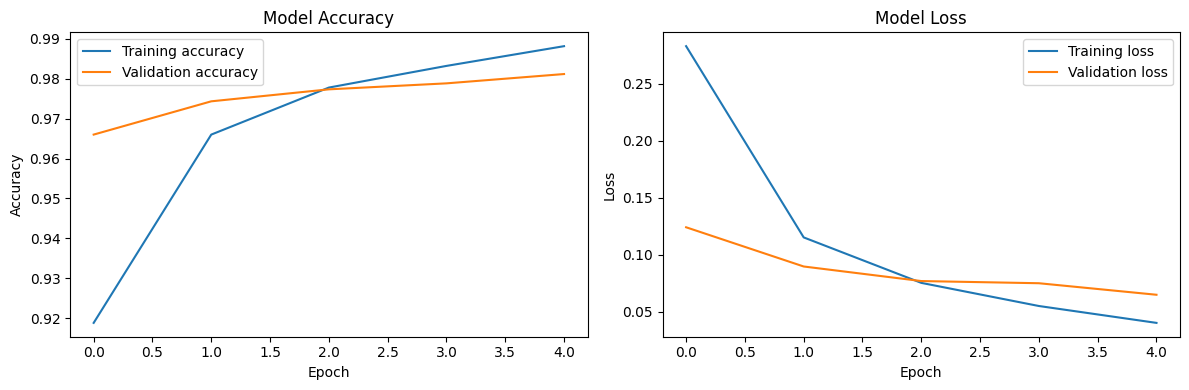

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Training accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Training loss')
axes[1].plot(history.history['val_loss'], label='Validation loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Evaluating the Model on the Test Set

After training we evaluate on the **held-out test set** — 10 000 images the model has never seen during training or validation.

`model.evaluate()` returns the same metrics configured during compilation: loss and accuracy.

The test accuracy reflects real-world performance. It is expected to be slightly lower than the training accuracy.  
According to the lab example, a 5-epoch run with 512 hidden units should reach approximately **97.7 %** test accuracy.

In [9]:
test_loss, test_acc = network.evaluate(test_images, test_labels)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}  ({test_acc * 100:.2f} %)")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9789 - loss: 0.0644
Test loss:     0.0644
Test accuracy: 0.9789  (97.89 %)


#### Saving the Trained Model

`model.save()` serialises the entire model — architecture, weights, optimiser state — into a single file.

We use the **`.keras` format** (recommended since TensorFlow 2.12+). It is a ZIP archive that stores:
- `config.json` — model architecture
- `model.weights.h5` — trained weight values
- `metadata.json` — Keras version info

The saved file can later be restored with `load_model('mnist_model.keras')` and used for inference without retraining.

In [25]:
network.save('mnist_model.keras')
print("Model saved to: mnist_model.keras")

Model saved to: mnist_model.keras


#### Loading and Preprocessing Custom Digit Images

We test the trained model on 4 handwritten digit images created in a graphics editor and stored in the `my_digits/` folder:
`digit1.png`, `digit3.png`, `digit4.png`, `digit9.png`.

Each image goes through the following preprocessing pipeline to match the MNIST training format:

1. **Grayscale conversion** — MNIST images are single-channel; colour information is discarded.
2. **Resize to 28 × 28** — matches the resolution the network was trained on.
3. **Colour inversion** (`255 − pixel`) — MNIST uses **white digit on black background**, while typical paint applications produce **black digit on white background**. Inversion aligns the two conventions.
4. **Normalise to [0, 1]** — divide by 255, matching the training data preprocessing.
5. **Reshape to (1, 784)** — flatten and add the batch dimension expected by the model.

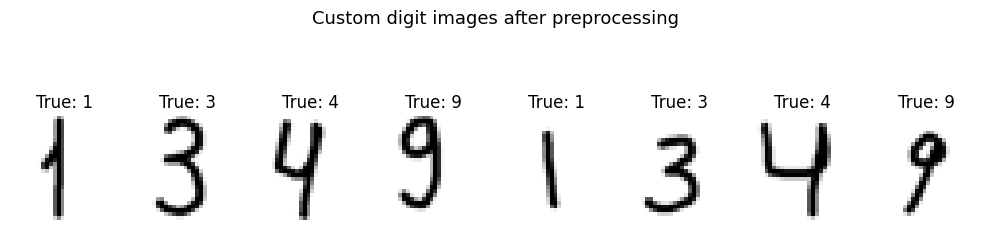

In [29]:
digit_files = [
    ('my_digits/digit1.png', 1),
    ('my_digits/digit3.png', 3),
    ('my_digits/digit4.png', 4),
    ('my_digits/digit9.png', 9),
    ('my_digits/digit1_1.png', 1),
    ('my_digits/digit3_1.png', 3),
    ('my_digits/digit4_1.png', 4),
    ('my_digits/digit9_1.png', 9)
]

fig, axes = plt.subplots(1, 8, figsize=(10, 3))
processed = []

for ax, (path, true_label) in zip(axes, digit_files):
    img = Image.open(path).convert('L')       # grayscale
    img = img.resize((28, 28))                # resize to MNIST resolution
    arr = 255 - np.array(img)                 # invert colours
    arr = arr.astype('float32') / 255         # normalise
    processed.append((arr.reshape(1, 784), true_label))

    ax.imshow(arr, cmap=plt.cm.binary)
    ax.set_title(f'True: {true_label}')
    ax.axis('off')

plt.suptitle('Custom digit images after preprocessing', fontsize=13)
plt.tight_layout()
plt.show()

#### Recognising Custom Digits with the Trained Model

We reload the saved model and pass each preprocessed image through `model.predict()`.  
The output is a **probability vector of length 10**, where the *i*-th element is the model's confidence that the digit is *i*.

The predicted digit is the index with the highest probability — `np.argmax(predictions)`.

For each image we show:
- **Left**: the preprocessed 28 × 28 image with true vs. predicted label
- **Right**: a bar chart of all 10 class probabilities — the predicted class is highlighted in red, giving a visual sense of the model's confidence

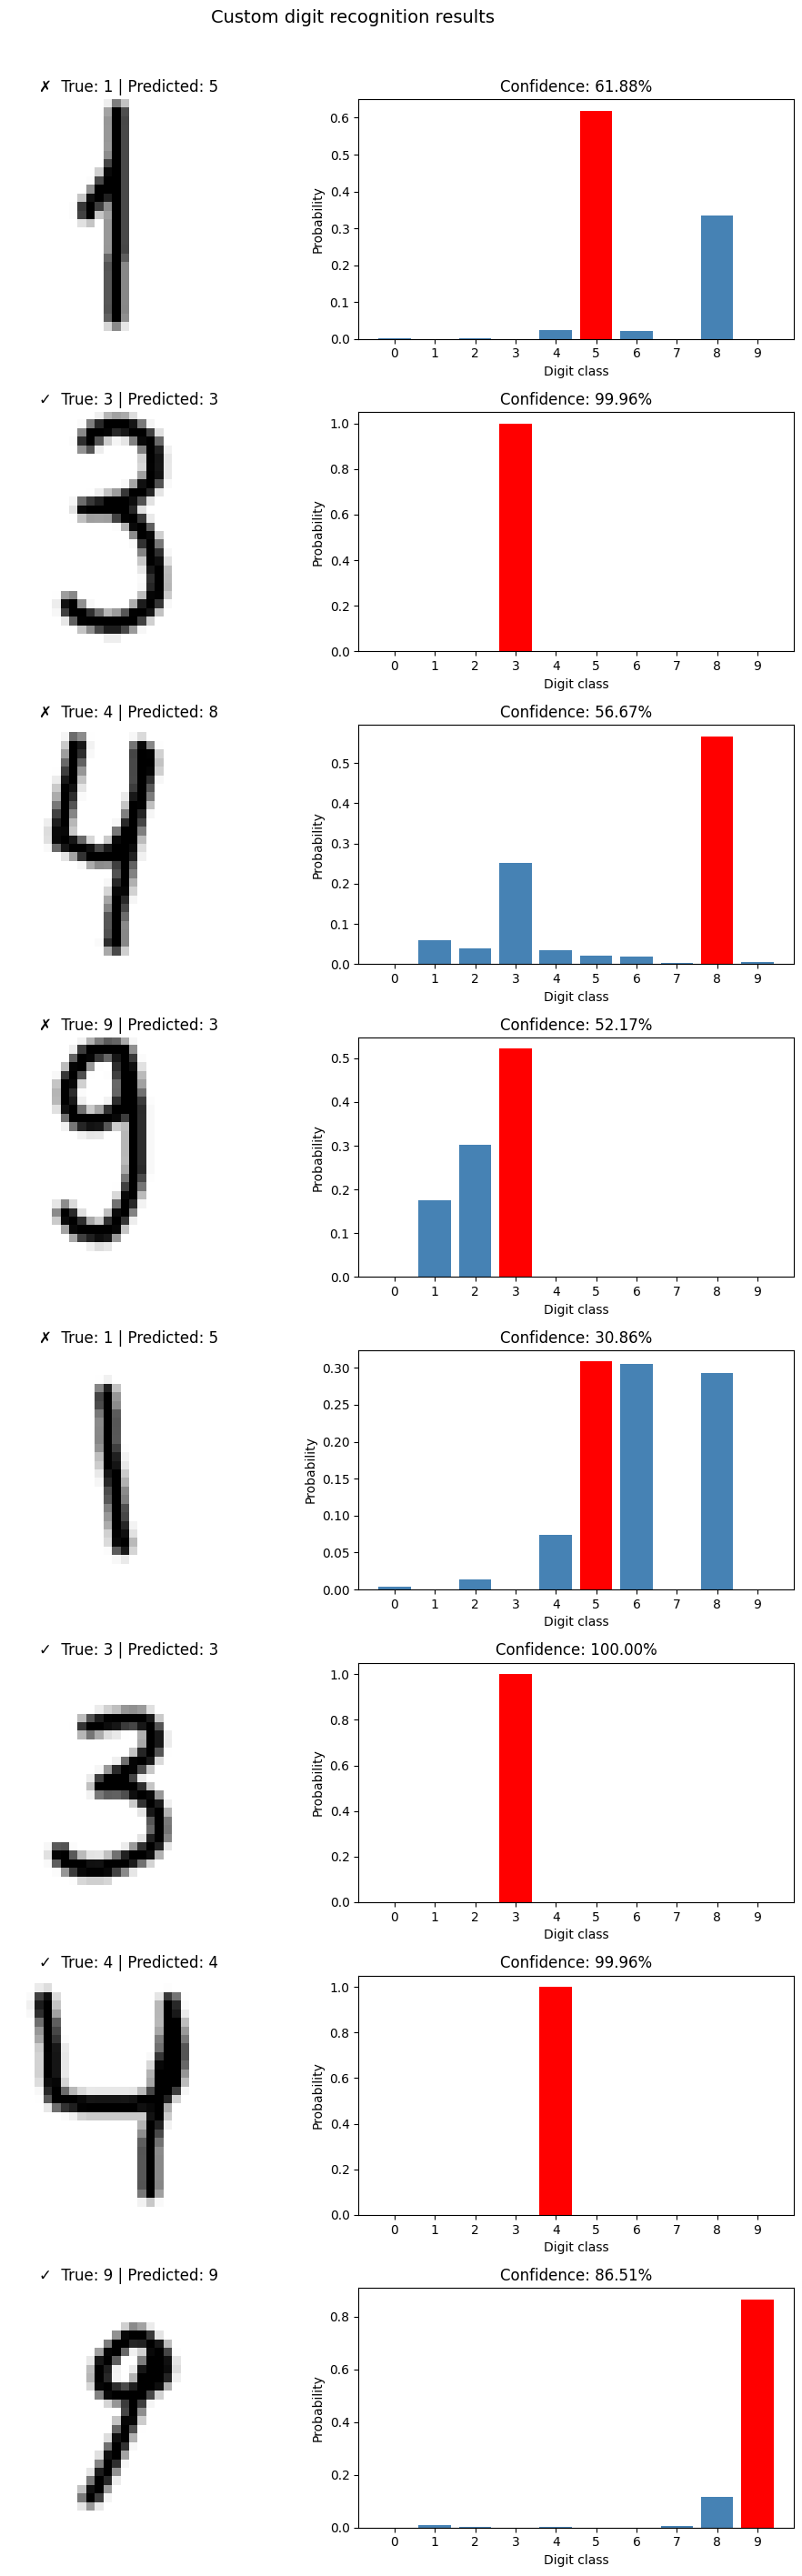

In [31]:
from tensorflow.keras.models import load_model

model = load_model('mnist_model.keras')

fig, axes = plt.subplots(8, 2, figsize=(10, 28))

for i, (img_array, true_label) in enumerate(processed):
    preds = model.predict(img_array, verbose=0)[0]
    predicted = np.argmax(preds)
    correct = '✓' if predicted == true_label else '✗'

    # Image
    axes[i, 0].imshow(img_array.reshape(28, 28), cmap=plt.cm.binary)
    axes[i, 0].set_title(f'{correct}  True: {true_label} | Predicted: {predicted}', fontsize=12)
    axes[i, 0].axis('off')

    # Probability bar chart
    bar_colors = ['red' if j == predicted else 'steelblue' for j in range(10)]
    axes[i, 1].bar(range(10), preds, color=bar_colors)
    axes[i, 1].set_xticks(range(10))
    axes[i, 1].set_xlabel('Digit class')
    axes[i, 1].set_ylabel('Probability')
    axes[i, 1].set_title(f'Confidence: {preds[predicted]:.2%}')

plt.suptitle('Custom digit recognition results', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### Conclusions

In this task, we reproduced the MNIST handwritten-digit classification example from the lab manual and extended it by testing the trained model on two sets of custom images.

**Key results:**
- A simple two-layer fully-connected network (784 → 512 ReLU → 10 Softmax) trained for **5 epochs** achieves approximately **~98%** accuracy on the 10,000-image test set — consistent with the lab example.
- The `rmsprop` optimiser with `categorical_crossentropy` loss converges stably, with validation metrics closely tracking training metrics, indicating no significant overfitting.

**Custom image testing & Style Influence:**
The model was tested on two batches of hand-drawn digits (1, 3, 4, 9) to evaluate its robustness:
1. **Freehand Batch (Initial Style):** Only **1 out of 4** (the digit '3') was correctly identified. The model struggled with atypical styles.
2. **MNIST-Style Batch:** After observing the original dataset's style (simpler strokes, specific proportions), the accuracy improved to **3 out of 4** correct predictions.
3. **Critical Preprocessing:** Colour inversion is essential because the model is trained on white-on-black pixels. Without it, the network fails to see any patterns.

**Analysis of Results:**
The experiment highlights that a Dense (fully-connected) architecture is highly sensitive to the spatial distribution of pixels. Even a high-accuracy model (~98% on test data) can fail on real-world inputs if they deviate from the training style (data distribution).

**Takeaway:** 
While shallow dense networks solve MNIST effectively, they lack geometric invariance. For more challenging and diverse datasets like CIFAR-10 or Fashion-MNIST, convolutional layers are needed to capture features regardless of minor style variations or shifts.